In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

In [10]:
def qproj00():
    return basis(2, 0).proj()


def qproj11():
    return basis(2, 1).proj()


def qproj01():
    op = np.array([[0, 1], [0, 0]])
    return Qobj(op)


def qproj10():
    op = np.array([[0, 0], [1, 0]])
    return Qobj(op)

In [ ]:
N = 100        # cutoff
delta = 0.222
N_rounds = 9
alpha = np.sqrt(np.pi) 

a = destroy(N)
x = position(N)
p = momentum(N)

r = -np.log(delta) 
squeezing_operator = squeeze(N, r)
vac = basis(N, 0)
state = tensor(basis(2,0),squeezing_operator * vac)

def conditional_displacement(alpha):
    D_plus = displace(N, alpha)
    D_minus = displace(N, -alpha)
    return tensor(qproj00(),D_plus) + tensor(qproj11(),D_minus)

def Ux_operator(theta,alpha,delta):
    CD_real = tensor(sigmax(),1j*(theta/alpha)*position(N)).expm()
    CD_imag = tensor(sigmay(),1j*(2*theta/alpha)*(delta**2)*momentum(N)).expm()
    return CD_real * CD_imag

for k in range(1,N_rounds):
    state = conditional_displacement(alpha) * state
    state = Ux_operator(alpha,4*k,delta) * state


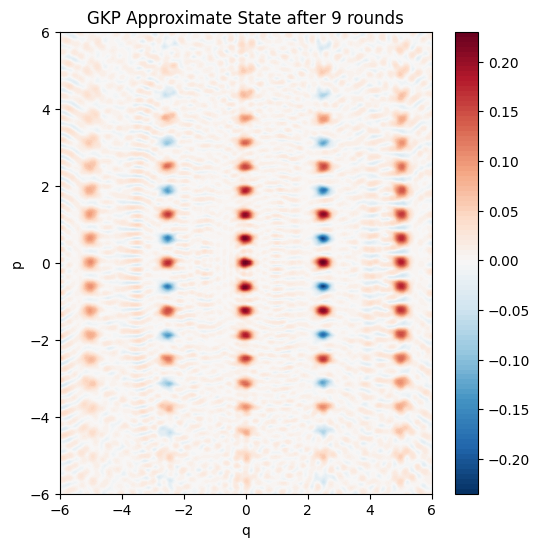

In [ ]:
xvec = np.linspace(-6, 6, 300)
W = wigner(state, xvec, xvec)

plt.figure(figsize=(6,6))
plt.contourf(xvec, xvec, W, 100, cmap='RdBu_r')
plt.colorbar()
plt.title(f"GKP Approximate State")
plt.xlabel('q')
plt.ylabel('p')
plt.show()